In [44]:

# ── Wall region definitions — loaded from analysis/segment.py ─────────────
from segment import WALL_REGIONS, surf_id_to_region, DEST_ORDER

print("Region → surf ID ranges:")
for name, ids in WALL_REGIONS.items():
    print(f"  {name:20s}: {min(ids):3d} – {max(ids):3d}  ({len(ids)} elements)")
print(f"  Total wall elements: {sum(len(v) for v in WALL_REGIONS.values())}")


Region → surf ID ranges:
  lfs_wall            :   1 – 156  (55 elements)
  upper_outer_div     :  50 –  63  (14 elements)
  crown               :  64 –  82  (19 elements)
  upper_inner_div     :  83 –  90  (8 elements)
  hfs_wall            :  91 – 109  (19 elements)
  lower_inner_div     : 110 – 117  (8 elements)
  dome                : 118 – 136  (19 elements)
  lower_outer_div     : 137 – 150  (14 elements)
  Total wall elements: 156


Number of points:  296
Number of lines:  296


/Users/42d/OpenedgeGPU/examples/test_droplet/analysis/segment.py:131: UserWarning: This figure includes Axes that are not compatible with tight_layout, so results might be incorrect.
  plt.tight_layout()


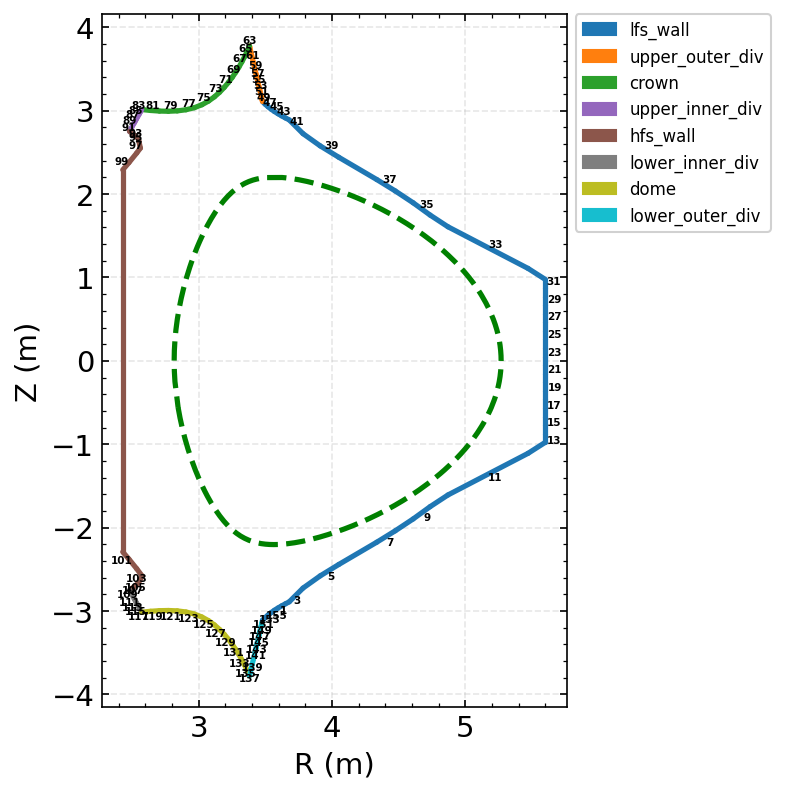

Saved → /Users/42d/OpenedgeGPU/examples/test_droplet/Figs/wall_surf_ids.png


In [45]:

# ── Wall surf ID diagnostic plot ──────────────────────────────────────────

from segment import plot_wall_ids
plot_wall_ids()


In [46]:

# ── Transfer matrix: load surf dump ─────────────────────────────────────────
# fix ave/surf uses "ave running": value at step T = total_hits / T.
# Multiply the LAST block's values by its timestep → integer hit totals.

import pandas as pd

SURF_DUMP = "/Users/42d/OpenedgeGPU/examples/test_droplet/tmp.all.surf"

def read_surf_blocks(path):
    """Read all ITEM: SURFS blocks; return list of (timestep, DataFrame)."""
    blocks = []
    with open(path) as fh:
        lines = fh.readlines()
    i = 0
    current_ts = None
    while i < len(lines):
        line = lines[i].strip()
        if line == "ITEM: TIMESTEP":
            current_ts = int(lines[i + 1].strip())
            i += 2
        elif line.startswith("ITEM: SURFS"):
            col_names = line.split()[2:]
            i += 1
            rows = []
            while i < len(lines) and not lines[i].strip().startswith("ITEM:"):
                parts = lines[i].split()
                if parts:
                    rows.append({col: float(v) for col, v in zip(col_names, parts)})
                i += 1
            if rows:
                df = pd.DataFrame(rows)
                df['id'] = df['id'].astype(int)
                blocks.append((current_ts, df))
        else:
            i += 1
    return sorted(blocks, key=lambda x: x[0])

blocks = read_surf_blocks(SURF_DUMP)
blocks = [(ts, df) for ts, df in blocks if ts > 0]   # skip step-0 init block

last_ts, last_df = blocks[-1]
sp_cols = [c for c in last_df.columns if c != 'id']

# running mean × timestep → total integer hit count
surf_df = last_df[['id']].copy()
surf_df['inner'] = (last_df[sp_cols[0]] * last_ts).round().astype(int)
surf_df['outer'] = (last_df[sp_cols[1]] * last_ts).round().astype(int)

print(f"Last block: timestep={last_ts}, {len(surf_df)} surf elements")
print(f"Total inner hits: {surf_df['inner'].sum()}")
print(f"Total outer hits: {surf_df['outer'].sum()}")


Last block: timestep=14800, 156 surf elements
Total inner hits: 0
Total outer hits: 440


In [47]:
surf_df

,id,inner,outer
0,1,0,0
1,5,0,0
2,9,0,0
3,13,0,0
4,17,0,0
...,...,...,...
151,140,0,0
152,144,0,0
153,148,0,0
154,152,0,0


In [48]:

# ── Build destination map: surf_id → wall region or "core" ─────────────────
# Wall surf IDs : 1–156   (read_surf wall.surf  loaded first)
# Core surf IDs : 157–452 (read_surf core.surf  loaded second)
# wall_segments must already be defined (cell 76).

import sys, os
import numpy as np
from shapely.geometry import LineString

sys.path.insert(0, os.path.dirname(os.path.abspath(".")))   # add test_droplet to path
from analysis.utils import Surface3

# surf_df is produced by cell 86 (read_surf_blocks + integer conversion)
print(f"Loaded {len(surf_df)} surf elements, timestep={last_ts}")
print(surf_df[surf_df[['inner','outer']].sum(axis=1) > 0].head(10))


Loaded 156 surf elements, timestep=14800
      id  inner  outer
32   129      0     20
33   133      0    220
72   134      0     80
110  131      0     20
111  135      0     20
149  132      0     80


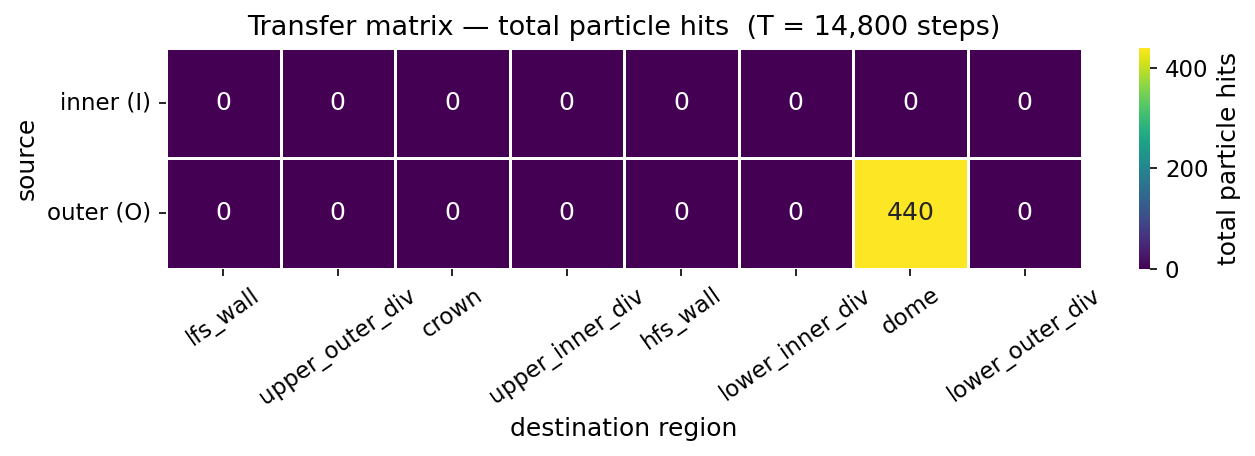

Saved → Figs/transfer_matrix.png


In [49]:

# ── Transfer matrix: single clean heatmap ────────────────────────────────────
import matplotlib.pyplot as plt
import seaborn as sns
import os

# surf_df produced by cell 86 (integer hit counts in 'inner' and 'outer')
# DEST_ORDER and surf_id_to_region defined in cell 76

surf_df['dest'] = surf_df['id'].apply(surf_id_to_region)

# aggregate by destination
agg = surf_df.groupby('dest')[['inner', 'outer']].sum()
agg = agg.reindex([d for d in DEST_ORDER if d in agg.index], fill_value=0)

# build matrix: rows = source species, columns = destinations
matrix = agg.T.copy()
matrix.index   = ['inner (I)', 'outer (O)']
matrix.columns.name = 'destination'

# ── plot ─────────────────────────────────────────────────────────────────────
plt.rcParams.update({
    "font.size": 12,
    "axes.labelsize": 12,
    "axes.titlesize": 13,
    "xtick.labelsize": 11,
    "ytick.labelsize": 11,
})

n_dest = matrix.shape[1]
fig, ax = plt.subplots(figsize=(max(9, n_dest * 1.1), 3.2), dpi=150)

sns.heatmap(
    matrix, ax=ax,
    annot=True, fmt="d",
    cmap="viridis",
    linewidths=0.5,
    cbar_kws={"label": "total particle hits"},
)
ax.set_title(f"Transfer matrix — total particle hits  (T = {last_ts:,} steps)")
ax.set_xlabel("destination region")
ax.set_ylabel("source")
ax.tick_params(axis='x', rotation=35)
ax.tick_params(axis='y', rotation=0)

plt.tight_layout()
os.makedirs("/Users/42d/OpenedgeGPU/examples/test_droplet/Figs", exist_ok=True)
plt.savefig("/Users/42d/OpenedgeGPU/examples/test_droplet/Figs/transfer_matrix.png",
            dpi=200, bbox_inches="tight")
plt.show()
print("Saved → Figs/transfer_matrix.png")
